## Concept Overview

In Logistic Regression, we want to predict the probability that a given input $x$ belongs to a the positive class (1): 

$\hat{y} = P(y = 1 \mid x)$


Since probabilities must stay between $0$ and $1$, we do not simply use a linear function like

$
w^T x + b.
$

Instead, we first define the linear term $z = w^T x + b,$ and then pass it through the **Sigmoid function**, defined as

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

This S-shaped curve acts as a squashing function:

- When $z$ is a very large positive number, $e^{-z} \to 0$, so  
  $$
  \sigma(z) \to 1.
  $$

- When $z$ is a very large negative number, $e^{-z}$ becomes very large, making the denominator grow significantly, so  
  $$
  \sigma(z) \to 0.
  $$

Thus, the sigmoid function ensures that the output always remains between $0$ and $1$, making it suitable for modeling probabilities.


### Sigmoid
![sigmoid-curve](../images/sigmoid-curve.png)

$\sigma(x) = \frac{1}{1 + e^{-z}}$
- Squashes input into the range (0, 1). 
- Used for binary classification where the output is the probability of a single class being positive
- Suffers from vanishing gradients — when inputs are very positive or very negative, the gradient becomes extremely small, slowing or stopping learning.

In [1]:
import torch

In [2]:
z_values = torch.arange(-4, 5, 2)
z_values

tensor([-4, -2,  0,  2,  4])

In [3]:
torch.sigmoid(z_values)

tensor([0.0180, 0.1192, 0.5000, 0.8808, 0.9820])

## Loss vs. Cost Function

The **Loss function** $\mathcal{L}(\hat{y}, y)$ measures error for a single training example, while the **Cost function** $J(w, b)$ measures the average error across the entire training set of $m$ examples.

**1. The Loss Function (Cross-Entropy)**

To ensure a convex optimization surface, we use:
$$\mathcal{L}(\hat{y}, y) = -(y \log \hat{y} + (1-y) \log(1-\hat{y}))$$

This formula automatically adapts based on the ground truth $y$:

- If $y = 1$: 
$\mathcal{L}(\hat{y}, y) = -\log \hat{y}$
  - Goal: $\hat{y} \rightarrow 1$ (Loss $\rightarrow 0$).
- If $y = 0$: $\mathcal{L}(\hat{y}, y) = -\log(1-\hat{y})$ 
  - Goal: $\hat{y} \rightarrow 0$ (Loss $\rightarrow 0$). 

**2. The Cost Function**

The cost is the arithmetic mean of all individual losses:$$J(w, b) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}(\hat{y}^{(i)}, y^{(i)})$$Full expanded form:$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{y}^{(i)} + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

**Why do we multiply the loss function by $-1$?**
- Because the logarithm of any number between 0 and 1 is always negative and since Logistic Regression outputs probabilities, $log (\hat{y})$ will always be negative. Therefore, we multiply the result of the loss function with -1 to transform it into a positive loss that gradient descent can minimize. 

In [4]:
torch.log(torch.tensor(0.9))

tensor(-0.1054)

## Deriving the Gradient for Logistic Regression
Let's define the components:

* **Prediction:** $\hat{y} = \sigma(z)$ (where $\sigma$ is the sigmoid function $\frac{1}{1+e^{-z}}$)
* **Linear Logit:** $z = wx + b$
* **Loss:** $\mathcal{L} = -(y \log \hat{y} + (1-y) \log(1-\hat{y}))$

To find the derivative of the loss with respect to $w$, we chain them together:


$$\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$$

---

### Step 1: Derivative of Loss w.r.t Prediction ($\frac{\partial \mathcal{L}}{\partial \hat{y}}$)

Using the rules we discussed (treating $y$ as a constant), we differentiate the logs:

1. **Differentiate terms:**

$$\frac{\partial \mathcal{L}}{\partial \hat{y}} = -\left( \frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} \cdot (-1) \right) = -\left( \frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}} \right)$$


2. **Find common denominator:**

$$-\left( \frac{y(1-\hat{y}) - \hat{y}(1-y)}{\hat{y}(1-\hat{y})} \right)$$


3. **Expand and Simplify:** The numerator becomes $y - y\hat{y} - \hat{y} + y\hat{y} = y - \hat{y}$.
4. **Finalize:** Multiply by the leading negative to get $\hat{y} - y$.

**Result:** $\frac{\partial \mathcal{L}}{\partial \hat{y}} = \frac{\hat{y}-y}{\hat{y}(1-\hat{y})}$

### Step 2: Derivative of Prediction w.r.t Logit ($\frac{\partial \hat{y}}{\partial z}$)

This is a standard property of the Sigmoid function:


$$\frac{\partial \hat{y}}{\partial z} = \sigma(z)(1-\sigma(z)) = \hat{y}(1-\hat{y})$$

### Step 3: Derivative of Logit w.r.t Weight ($\frac{\partial z}{\partial w}$)

Using the "multiplier" rule for $z = wx + b$, where $x$ is the scaling factor:


$$\frac{\partial z}{\partial w} = x$$

---

### Putting it all together

Now we multiply the three parts:


$$\frac{\partial \mathcal{L}}{\partial w} = \underbrace{\left[ \frac{\hat{y}-y}{\hat{y}(1-\hat{y})} \right]}_{\text{Step 1}} \cdot \underbrace{\left[ \hat{y}(1-\hat{y}) \right]}_{\text{Step 2}} \cdot \underbrace{\left[ x \right]}_{\text{Step 3}}$$

Notice how the denominators in Step 1 perfectly cancel out the terms in Step 2!


$$\frac{\partial \mathcal{L}}{\partial w} = (\hat{y} - y)x$$

For the bias **$b$**, Step 3 becomes $\frac{\partial z}{\partial b} = 1$, so:


$$\frac{\partial \mathcal{L}}{\partial b} = \hat{y} - y$$

#### Logistic Regression with Stochastic Gradient Descent (SGD)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [ ]:
np.random.permutation(10)

array([3, 6, 8, 5, 9, 4, 0, 7, 2, 1])

In [8]:
X_raw, Y_raw = make_moons(n_samples=200, noise=0.15, random_state=42)
X_raw.shape, Y_raw.shape

((200, 2), (200,))

In [10]:
X_raw[:4]

array([[-1.07816119,  0.06336772],
       [ 0.93980859,  0.4571195 ],
       [ 0.69515144,  0.64210707],
       [ 1.1501734 , -0.34787103]])

##### Visualize the Data

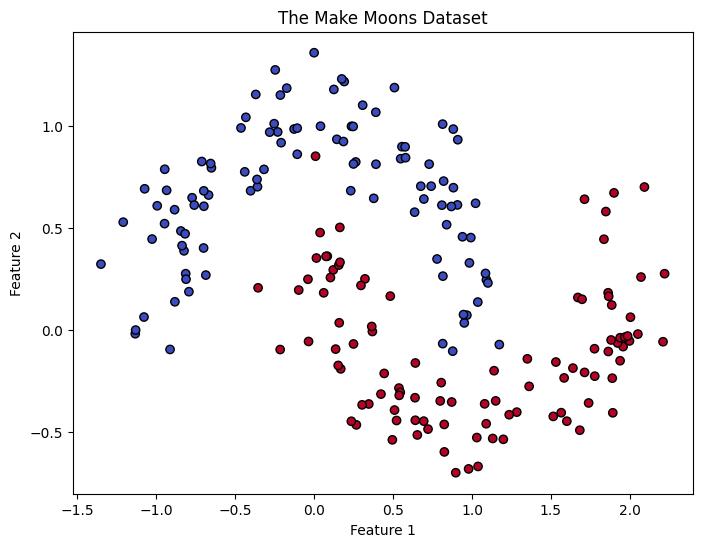

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=Y_raw, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("The Make Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [61]:
X_raw[:4]

array([[-1.07816119,  0.06336772],
       [ 0.93980859,  0.4571195 ],
       [ 0.69515144,  0.64210707],
       [ 1.1501734 , -0.34787103]])

In [62]:
X_raw[:4].T

array([[-1.07816119,  0.93980859,  0.69515144,  1.1501734 ],
       [ 0.06336772,  0.4571195 ,  0.64210707, -0.34787103]])

In [63]:
Y_raw[:4]

array([0, 0, 0, 1])

In [65]:
Y_raw[:4].reshape(1, -1)

array([[0, 0, 0, 1]])

##### Prepare the Data for Modelling

In [74]:
# Our model expects X to be (features, m) and Y to be (1, m) where m is the number of samples
X = X_raw.T 
Y = Y_raw.reshape(1, -1)
n_feat, m = X.shape
X_raw.shape, Y_raw.shape, X.shape, Y.shape

((200, 2), (200,), (2, 200), (1, 200))

In [75]:
n_feat, m

(2, 200)

In [76]:
X[:, 0]

array([-1.07816119,  0.06336772])

In [77]:
X_raw[0]

array([-1.07816119,  0.06336772])

In [79]:
Y[:, 0]

array([0])

##### SGD Implementation

In [68]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
def sgd(X, Y, epochs=100, lr=0.1):
    w = np.zeros((n_feat, 1))
    b = 0.0
    costs = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        epoch_loss = []
        for i in indices:
            # Pick one random sample
            x = X[:, i]
            y = Y[:, i]

            # Make predictions
            logit = np.dot(w.T, x) + b
            y_pred = sigmoid(logit)

            # Compute the error and update the params
            error = y_pred - y
            w_grad = error * x
            b_grad = error
            w -= lr * w_grad.reshape(-1, 1)
            b -= lr * b_grad

            # Compute the loss
            epsilon = 1e-8 # Safety net to prevent np.log(0) when y_pred is 0
            loss = -(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))
            epoch_loss.append(loss)
        avg_epoch_loss = np.mean(epoch_loss)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}: {avg_epoch_loss}")

        # Append epoch loss to costs
        costs.append(avg_epoch_loss)
    return w, b, costs

In [168]:
w, b, costs = sgd(X, Y)

Epoch: 0: 0.43748289619959235
Epoch: 10: 0.29833279312783423
Epoch: 20: 0.29359031579446443
Epoch: 30: 0.2989010115247631
Epoch: 40: 0.29959636711002724
Epoch: 50: 0.2943523856131087
Epoch: 60: 0.29966833323967657
Epoch: 70: 0.297890913414022
Epoch: 80: 0.29915332399831296
Epoch: 90: 0.2985752868892994


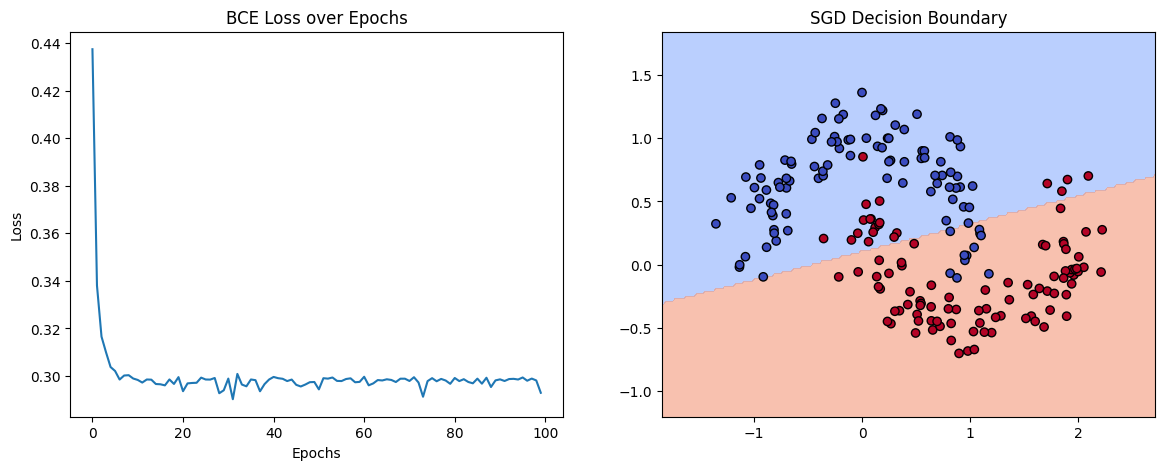

In [171]:
# Plot Results
def plot_results(w, b, X, Y, costs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Learning Curve
    ax1.plot(costs)
    ax1.set_title("BCE Loss over Epochs")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    
    # Plot 2: Decision Boundary
    x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
    y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    Z = sigmoid(np.dot(w.T, np.c_[xx.ravel(), yy.ravel()].T) + b)
    Z = (Z > 0.5).reshape(xx.shape)
    
    ax2.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6)
    ax2.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap=plt.cm.coolwarm, edgecolors='k')
    ax2.set_title("SGD Decision Boundary")
    plt.show()

plot_results(w, b, X, Y, costs)